# Debugging Notebook for functions

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from trainer import *
from mesh import *
from baseline import *
from metrics import *
#from main import *
import numpy as np
import matplotlib.pyplot as plt

# Loading data from mnist set
Functions in encoding.py

train:   160 samples, class counts {1: 80, 7: 80}
test :    40 samples, class counts {1: 20, 7: 20}
Number of '7' in this set: 80, number of '1' in this set: 80


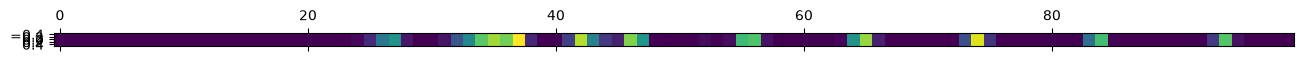

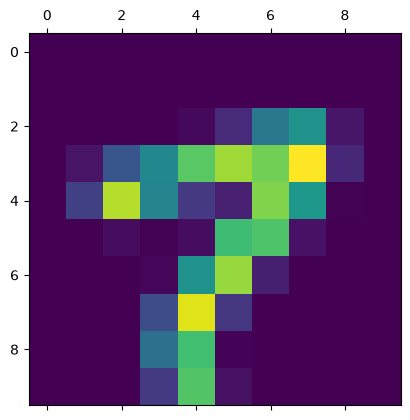

In [ ]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 200            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio)    
#E_* are the flattened arrays of the encoded mnist images (complex valued), 
#Y_* are the referring labels

#Example of the first entry
plt.matshow(np.real(E_train[:,0]).reshape(1, -1), ) #reshaping it just for plotting with plt.matshow
plt.matshow(np.real(E_train[:,0]).reshape(m_side,m_side))

print("Number of '7' in this set: " + str(np.sum(Y_train == 7))+", number of '1' in this set: " + str(np.sum(Y_train == 1)))


# Initializing MZI-Mesh
Functions in mesh.py
(No parameter initialization yet)

Number of layers in the setup: 4
MZIs along the layers in the setup: [2, 1, 2, 1]
Total number of (trainable) MZIs in the setup: 6


<Axes: title={'center': 'N=4, 4 Layer, 6 MZIs'}, xlabel='Layer', ylabel='Channel'>

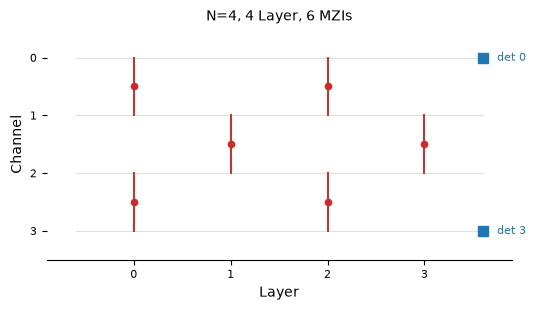

In [4]:
N=4 #Number of channels
L=4 #Number of layers
test_plan = plan_rectangular(N, L) #other plans are plan_redundant and plan_triangular
test_mesh = MZIMesh(N, test_plan) #Object containing the geometry of the MZI-Mesh

#Each mesh object carries its properties:
n_layers = test_mesh.n_layers
n_slots = test_mesh.slot_counts
n_mzis = test_mesh.n_mzis
print(f"Number of layers in the setup: {n_layers}") #layers of setup
print(f"MZIs along the layers in the setup: {n_slots}") #distribution of MZIs along the layers
print(f"Total number of (trainable) MZIs in the setup: {n_mzis}") #number of (trainable MZIs in this setup)

plot_mesh(test_mesh, color_by=None, detectors=[0, 3], label_step=None) #function of visualize.py to show the geometry (and detectors)


# Initializing Mesh parameters
Functions in mesh.py, here just init_random, also init_haar already coded (later used)

Phis: [array([4.12038942, 1.30159425]), array([4.2655283]), array([0.75441241, 5.88102627]), array([5.68483643])]
Thetas: [array([1.16659796, 2.36719233]), array([2.48959901]), array([2.66539402, 0.30240815]), array([0.05952783])]


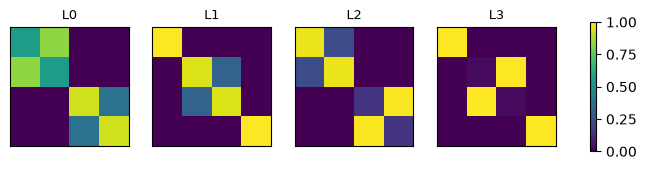

In [5]:
thetas, phis = test_mesh.init_random()
print(f"Phis: {phis}")
print(f"Thetas: {thetas}")

layers = test_mesh.layer_matrices(thetas, phis)   #building layers (transfer matrices) out of the parameters
fig, _ = plot_layers(layers, mode="Abs")


# Propagation

[[-0.02891781-0.0071079j  -0.0456768 -0.01199759j -0.02113654-0.00948891j
  ... -0.00728018+0.00351574j -0.04658619-0.01618539j
  -0.03233378-0.00237177j]
 [-0.02094401-0.00793245j -0.04896123-0.01675458j -0.02863592-0.01482174j
  ... -0.00702325+0.00131621j -0.04964461-0.01599769j
  -0.03246726-0.00495578j]
 [ 0.01486624-0.0147428j   0.01713319-0.00748753j  0.0203202 -0.01284797j
  ...  0.00212186-0.00301754j  0.02240317-0.00972095j
   0.01584394-0.01139805j]
 ...
 [-0.03641274+0.01442656j  0.00481518+0.02268924j  0.02061667+0.02258135j
  ... -0.00110657+0.01041627j  0.00640936+0.0297085j
   0.06205617+0.00647613j]
 [-0.02966763+0.00847726j -0.0392963 +0.00829732j -0.02431806+0.01059184j
  ...  0.02053701-0.00980749j -0.0378326 -0.00379793j
  -0.08280168-0.00478465j]
 [-0.06777484+0.04829747j -0.03877005+0.06842438j  0.04686861+0.04201653j
  ... -0.00743943+0.02112747j -0.01160365+0.09309358j
   0.01004627+0.0400948j ]]
(100, 160)
----------E_hist----------
[[[ 0.00000000e+00+0.000000

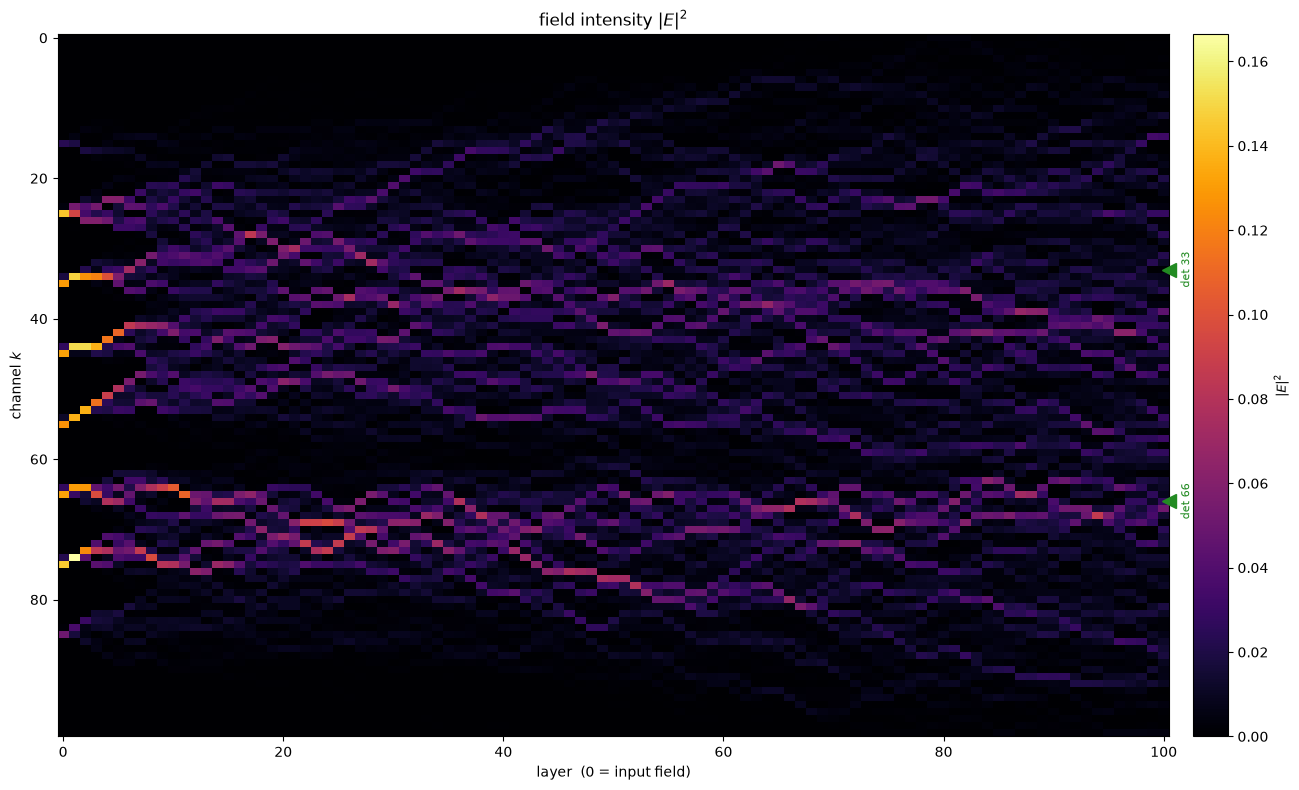

In [6]:
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices(thetas, phis)   #build transfer matrices (layers) from parameters

E_out  = forward(E_train, layers)         #propagation that gives end result directly
print(E_out)                          #format: [channels, batches]
print(np.shape(E_out))

E_hist = forward_history(E_train, layers) #propagation that gives all E-fields for every layer
print("-"*10+"E_hist"+"-"*10)
print(E_hist)                         #format: [layers, channels, batches]
print(np.shape(E_hist))
#Calculating and plotting intensity for one specific batch (2)
I = np.abs(E_hist[:,:,2])**2
fig, _ = plot_intensity_map(I, detectors=[33,66])

## Plotting intensity map with histogram
Over one specific propagation or a whole batch

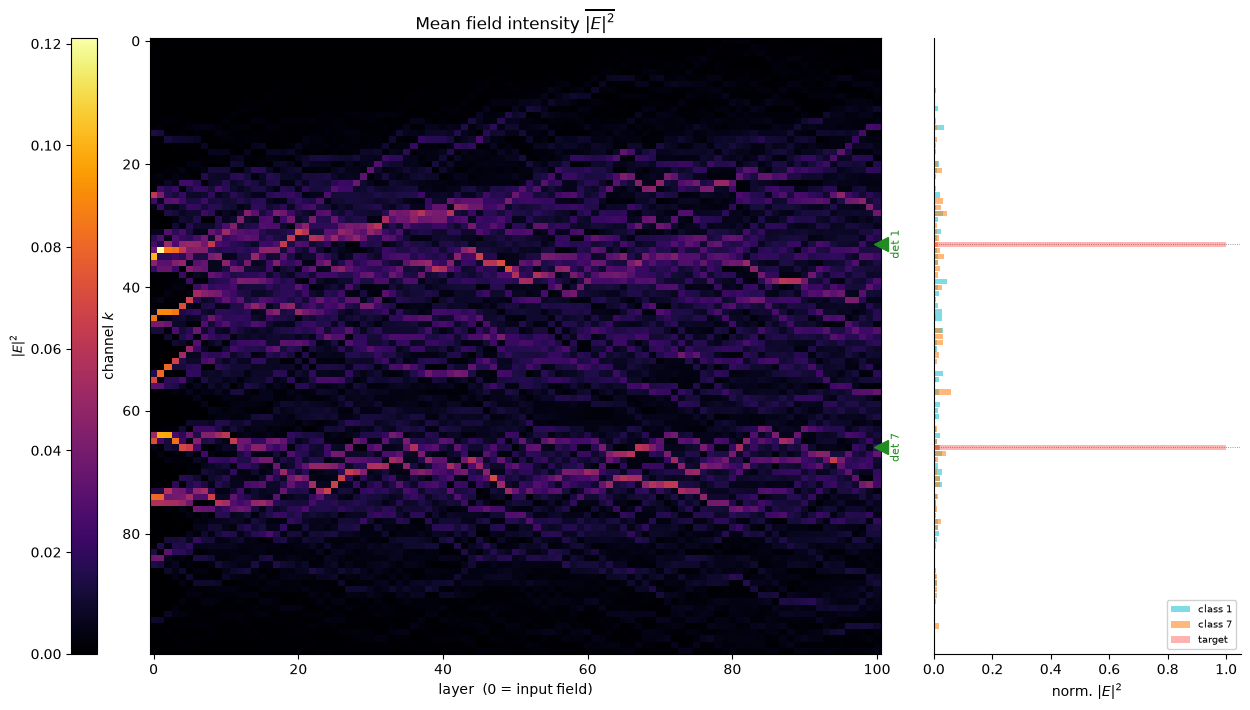

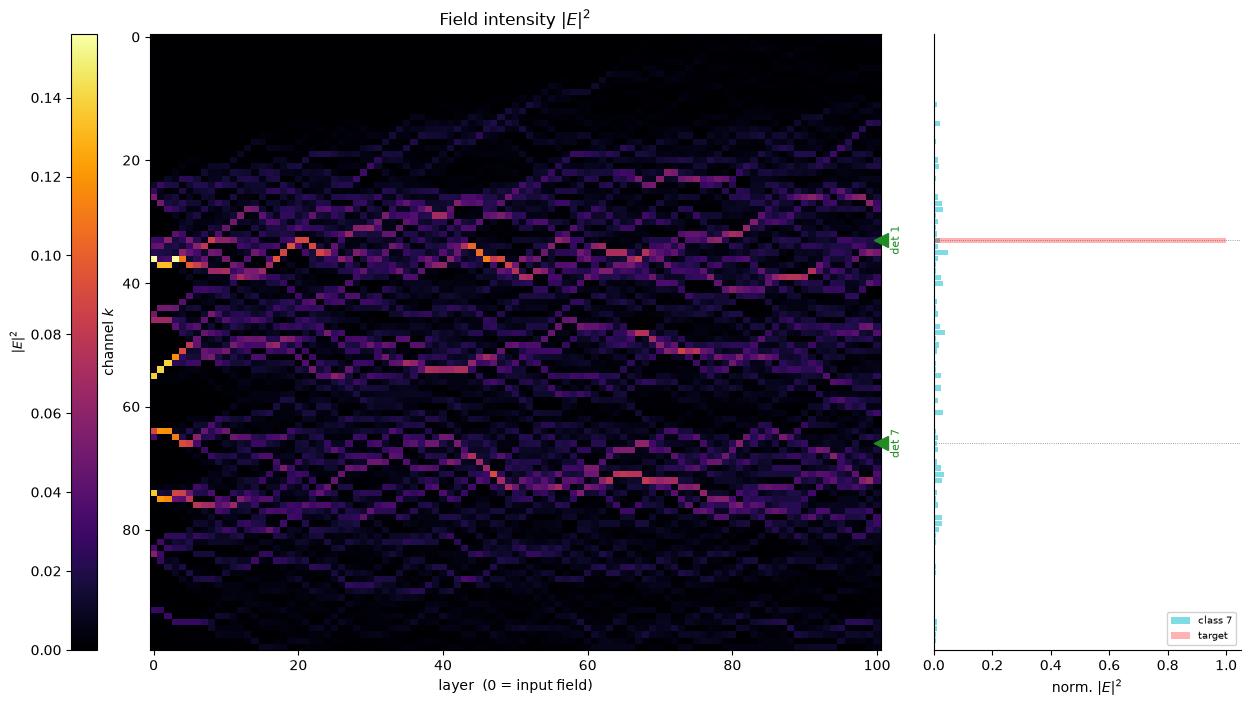

In [7]:
# Plotting over multiple batches accumulates the intensities for each of these values
fig, _ = plot_intensity_map_with_histogram(np.abs(E_hist[:,:,1:10])**2, det1=33, det7=66, Y=Y_train[1:10])
plt.show()
# eh?
fig, _ = plot_intensity_map_with_histogram(np.abs(E_hist[:,:,36])**2, det1=33, det7=66, Y=Y_train[36])
plt.show()

# Decoding

In [13]:
# Evaluating loss function by giving E_field (whole history "E_hist" or just final layer "E_hist[-1,:,:]") and the respective Y-values.
print(np.shape(E_hist))
print(np.shape(Y_train))
#Batchsize 160
loss=loss_function(E_hist, Y_train, 33, 66, kind="mse" ) #returns loss per batch (evaluated at the given detector positions)
print(loss)

(101, 100, 160)
(160,)
[0.97410033 0.94892796 0.99793951 0.95786085 0.99809055 0.99565291
 0.96481494 0.9641318  0.97881886 0.99776636 0.97288374 0.99307575
 0.99031738 0.98894485 0.98170093 0.97323826 0.98923306 0.98636842
 0.99973656 0.98569649 0.9587326  0.99311731 0.99174216 0.96477067
 0.98185298 0.99628508 0.99993002 0.96882229 0.98075875 0.98608671
 0.9716419  0.98505155 0.96415237 0.97221141 0.9622824  0.99625555
 0.98007259 0.97306204 0.98121524 0.94544252 0.97725429 0.99889228
 0.9995226  0.9974939  0.99808465 0.99301276 0.97633231 0.99731796
 0.98107465 0.9870782  0.97937321 0.98730905 0.99165523 0.98717724
 0.98231065 0.99065349 0.94525525 0.94779376 0.98653871 0.99108559
 0.9813125  0.99492126 0.9912759  0.99706712 0.98161572 0.97744324
 0.95932912 0.95995836 0.99692945 0.96024876 0.97608007 0.98868131
 0.98888925 0.98115851 0.98895872 0.98818586 0.95701826 0.99671119
 0.97876079 0.99478745 0.99655124 0.99302795 0.98247175 0.99744488
 0.99509787 0.95765716 0.98020861 0.995

# Linear regression
## m = 10
### No normalized energy

In [9]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
print(np.shape(E_X_Train))
E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy_val)

TypeError: slice indices must be integers or None or have an __index__ method

### Normalized energy

In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
#plt.matshow(np.real(E_X_Train[:,2]).reshape((28,28)))
E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy_val)

Training: 12530 samples, class counts {1: 6265, 7: 6265}
Testing: 2056 samples, class counts {1: 1028, 7: 1028}
0.9912451361867705


## Sweep over m
With normalized energy, balanced mode!
Takes ~4 minutes

In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total

#m_sweep = np.arange(1,29,1) #sweeping over side length (pixel) of mnist image (1 to 28)
accuracies_sweep = np.zeros(28)

theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = 42 #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration
for i,m in enumerate(m_sweep):
    E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed, balanced=True, verbose=True) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels
    #plt.matshow(np.real(E_X_Train[:,2]).reshape((28,28)))
    E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed, balanced=True, verbose=True) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels

    theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
    print(accuracy_val)
    accuracies_sweep[i]=accuracy_val.copy()

plt.plot(m_sweep, accuracies_sweep)

Training: 12530 samples, class counts {1: 6265, 7: 6265}
Testing: 2056 samples, class counts {1: 1028, 7: 1028}
0.5


KeyboardInterrupt: 

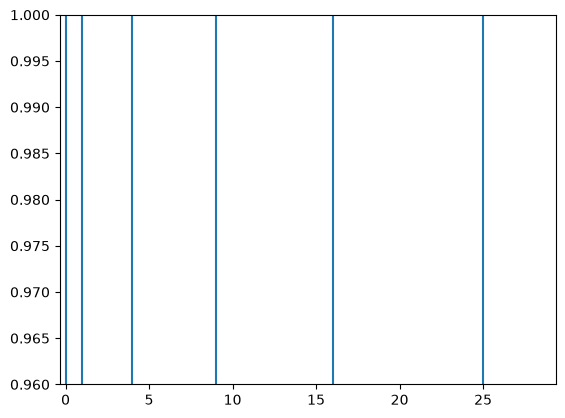

In [ ]:
plt.plot(m_sweep, accuracies_sweep)
plt.ylim((0.96,1))
[plt.axvline(x=y**2) for y in range(int(np.sqrt(36)))]

[[1028    0]
 [1028    0]]


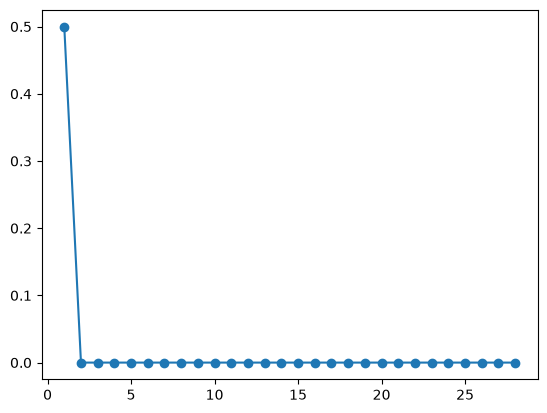

In [ ]:
print(conf_matrix)
plt.plot(m_sweep, accuracies_sweep, marker="o")

In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 1000 #Sets number of samples you want to get in total


m_sweep = [1] #sweeping over side length (pixel) of mnist image (1 to 28)
accuracies_sweep = np.zeros(28)

theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration
for i,m in enumerate(m_sweep):
    E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed, balanced=True, verbose=True) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels
    #plt.matshow(np.real(E_X_Train[:,2]).reshape((28,28)))
    E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed, balanced=True, verbose=True) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels

    theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
    print(accuracy_val)
    accuracies_sweep[i]=accuracy_val.copy()


Training: 1000 samples, class counts {1: 500, 7: 500}
Testing: 1000 samples, class counts {1: 500, 7: 500}
0.5


## Plotting intensity-differences between 7 and 1

In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels


Training: 12530 samples, class counts {1: 6265, 7: 6265}
Testing: 2056 samples, class counts {1: 1028, 7: 1028}


(100, 13007)


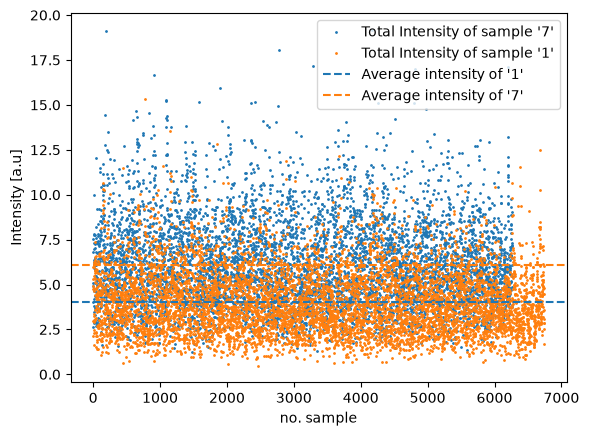

In [ ]:
print(np.shape(E_X_Train))
mask7 = Y_Train==7
mask1 = Y_Train==1

sumIntensity7 = np.sum(np.abs(E_X_Train[:,mask7])**2, axis=0)
sumIntensity1 = np.sum(np.abs(E_X_Train[:,mask1])**2, axis=0)
avgIntensity7 = np.mean(sumIntensity7)
avgIntensity1 = np.mean(sumIntensity1)
plt.plot(sumIntensity7, color="tab:blue", label="Total Intensity of sample '7'", linewidth=0.0, marker="o", markersize=1)
plt.plot(sumIntensity1, color="tab:orange", label="Total Intensity of sample '1'", linewidth=0.0, marker="o", markersize=1)
plt.axhline(y=avgIntensity1, color="tab:blue", linestyle="--", label="Average intensity of '1'")
plt.axhline(y=avgIntensity7, color="tab:orange", linestyle="--", label="Average intensity of '7'")
plt.ylabel("Intensity [a.u]")
plt.xlabel("no. sample")
plt.legend()

# Trainer

In [18]:
#Preparing Training and Test Data
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 42             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices_separate(thetas, phis)   #build transfer matrices (layers) from parameters

train:  1600 samples, class counts {1: 800, 7: 800}
test :   400 samples, class counts {1: 200, 7: 200}


In [ ]:
### CONFIG + MESH
cfg = TrainConfig(m_side=10, learning_rate=0.3, batch_size=64,
                  init="haar", max_epochs=100, patience=15, seed=0)
mesh = MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N))

trainer = Trainer(mesh, cfg)
history = trainer.fit(E_train, Y_train)          # nur noch ein Datensatz

### TRAINING
history = trainer.fit(E_train, Y_train, E_val, Y_val)
print(f"best val_acc {trainer.best['val_acc']:.4f} in epoch "
      f"{trainer.best['epoch']}, {len(history['val_acc'])} epochs, "
      f"{trainer.train_time:.1f}s")


### TEST -- genau EINMAL, mit den besten Gewichten
layers = mesh.layer_matrices_separate(trainer.thetas, trainer.phis, #Baue Mesh aus besten gefundenen Parametern
                                      cfg.eta_bs, cfg.alpha_fiber)
E_out = forward(E_test, layers)
y_hat = predict(E_out, *cfg.detectors)

conf = confusion_matrix(Y_test, y_hat, classes=(1, 7))
print_confusion(conf)
print(f"inference: {trainer.inference_time(E_test)*1e3:.2f} ms/sample")


### PLOTS
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_yscale("log"); ax[0].legend()
ax[1].plot(history["val_acc"])
ax[1].axhline(0.5, color="0.6", ls=":", label="chance level")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val accuracy"); ax[1].legend()
fig.tight_layout()

I = np.abs(forward_history(E_test, layers))**2
fig, _ = plot_intensity_map_with_histogram(I, *cfg.detectors, Y_test)

Example sweep over m:

In [ ]:
for m in (4, 6, 8, 10, 14):
    cfg = TrainConfig(m_side=m, seed=0)
    mesh = MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N))
    E_tr, y_tr = get_data(values, "Training", cfg.n_samples, cfg.m_side,
                          cfg.theta_enc, cfg.normalize_energy, cfg.seed)
                          #...

Training: 2000 samples, class counts {1: 1000, 7: 1000}
Training: 2000 samples, class counts {1: 1000, 7: 1000}
Training: 2000 samples, class counts {1: 1000, 7: 1000}
Training: 2000 samples, class counts {1: 1000, 7: 1000}
Training: 2000 samples, class counts {1: 1000, 7: 1000}
